In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [11]:
downloads = pd.read_csv("downloads.csv")
members = pd.read_csv("members.csv")

# merge downloads and members data on 'uid'
data = pd.merge(downloads, members, on = "uid", how = "left")
data.head(10)

,uid,supplier,image_id,res,dlType,date_download,dlyear,dlmonth,dlday,fraud,file_type,date_register,country,contributor
0,e98a4c15-2cb5-4ed1-b57f-30371300fd5f,8107867a-1f4a-4035-9c1d-8ed03d2ec2cd,197093672,mega,3,2024-09-30 23:59:55,2024,9,30,0,0,2021-08-16,TW,0
1,10870f27-fe41-4bae-8ed4-f93ee45210e8,76d62316-3394-4824-aa2b-117cc6f0ca83,16357128,NaN,2,2024-09-30 23:59:49,2024,9,30,0,1,2020-02-07,TH,0
2,79b326f5-eab7-4f18-92c2-608c184ace1d,4a160b61-23e1-42ef-b59a-4ea253f504bc,46529682,NaN,5,2024-09-30 23:59:41,2024,9,30,0,1,2013-05-06,KR,0
3,25267a99-0c27-49f9-bb8f-37c3359aeb21,da46eaba-d7ac-4c8a-9c40-ae0e46e68d08,84208353,NaN,5,2024-09-30 23:59:38,2024,9,30,0,1,2013-03-27,US,0
4,6515c23b-31ea-429e-a9f1-135cc4afcf3a,b3287ba9-40d6-4cfc-95d9-e4fd840889f1,174899950,med,3,2024-09-30 23:59:34,2024,9,30,0,0,2012-06-18,HK,0
5,63d57694-f757-41d7-81ad-e6ff54b1ca8b,737ff9cd-b245-434b-9275-bbc68f2ec407,95960728,NaN,2,2024-09-30 23:59:28,2024,9,30,0,0,2013-07-01,TW,0
6,114d95c9-c810-40c0-9a40-e800e1e77cd7,4a160b61-23e1-42ef-b59a-4ea253f504bc,88226777,NaN,2,2024-09-30 23:59:27,2024,9,30,0,1,2016-12-02,TW,0
7,6fba7c7d-cedb-4181-8d85-eda5a1bd64c2,7f2c5446-c825-4c00-b057-82ab25859333,199219547,NaN,2,2024-09-30 23:59:26,2024,9,30,0,22,2015-04-14,TW,0
8,63d57694-f757-41d7-81ad-e6ff54b1ca8b,a62fe1cf-29b5-4cc3-8c71-34409ee6d411,432143,NaN,2,2024-09-30 23:59:17,2024,9,30,0,0,2013-07-01,TW,0
9,4a67130d-06fd-4c62-bd6d-e9e4ad0379fe,ceddecb3-a720-47fe-bce4-a6d9cd797f96,107926716,NaN,2,2024-09-30 23:59:08,2024,9,30,0,0,2009-12-01,TW,0


In [ ]:
# convert date columns to datetime
data['date_download'] = pd.to_datetime(data['date_download'])
data['date_register'] = pd.to_datetime(data['date_register'])

dtype('<M8[ns]')

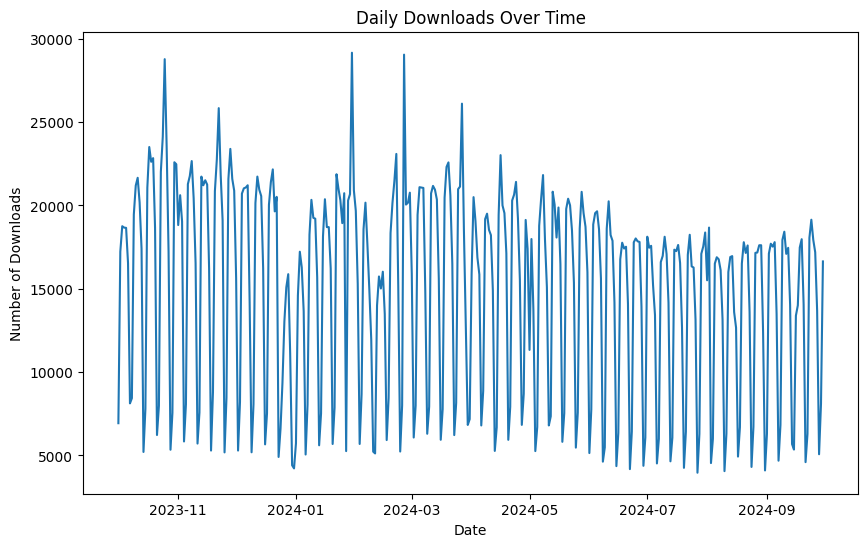

In [ ]:
# aggregate downloads by day
daily_downloads = data.groupby(data['date_download'].dt.date).size()

# plot daily downloads
plt.figure(figsize = (10, 6))
daily_downloads.plot(title = "Daily Downloads Over Time")
plt.ylabel("Number of Downloads")
plt.xlabel("Date")
plt.show()

In [16]:
# identify drop in downloads
rolling_avg = daily_downloads.rolling(window = 7).mean() # weekly rolling average
drop_date = daily_downloads.idxmin()
drop_value = daily_downloads.min()

print(f"The biggest drop occurred on {drop_date} with {drop_value} downloads.")

The biggest drop occurred on 2024-07-27 with 3962 downloads.


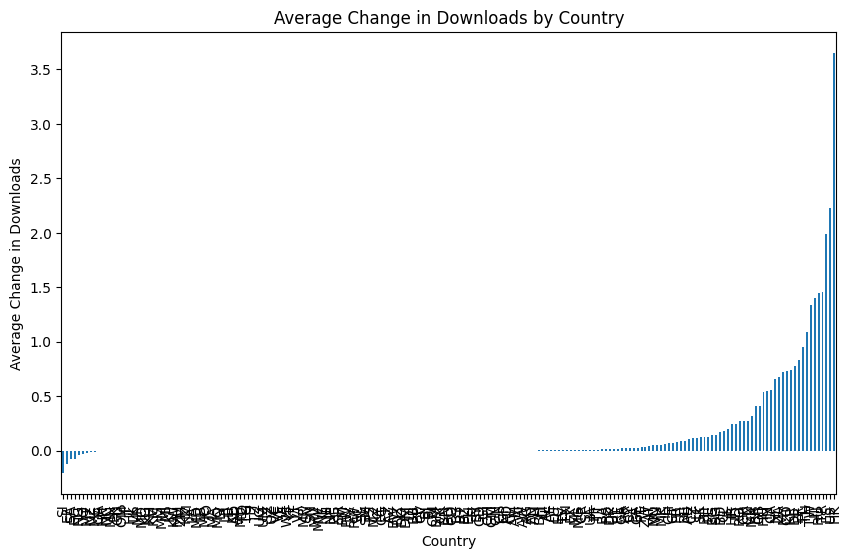

In [17]:
# group by country and calculate changes in downloads
country_trends = data.groupby(['country', data['date_download'].dt.date]).size().unstack(fill_value = 0)
country_changes = country_trends.diff(axis = 1).mean(axis = 1).sort_values()

plt.figure(figsize = (10, 6))
country_changes.plot(kind = "bar", title = "Average Change in Downloads by Country")
plt.ylabel("Average Change in Downloads")
plt.xlabel("Country")
plt.show()


In [18]:
user_trends = data.groupby(['uid', data['date_download'].dt.date]).size().unstack(fill_value = 0)
user_changes = user_trends.diff(axis = 1).sum(axis = 1).sort_values()
user_changes

uid
070894ee-b95b-420c-b04c-5fb9b213a2c6    -100.0
71fd4514-eb3e-4b93-a057-d183973c724a    -100.0
e9faee96-f3e1-4b8a-9147-063230b8d407    -100.0
42982fe8-a14d-4a35-b3b7-bfdb5f5f464c    -100.0
c477080d-ab5c-4054-bac4-3ea2f5ca9696    -100.0
                                         ...  
f22e8cfb-3213-4796-9489-3b2617aa4c9f     100.0
5e89fad3-0f5b-4942-84e7-b4d8577f6c1c     114.0
a84e8d2e-e56d-4510-bf1f-c461647c47cc     130.0
ae534d33-33be-483c-8210-a43320e0a90a     166.0
694979d0-7c6c-460f-b672-ab4753b98dd1    1028.0
Length: 84841, dtype: float64

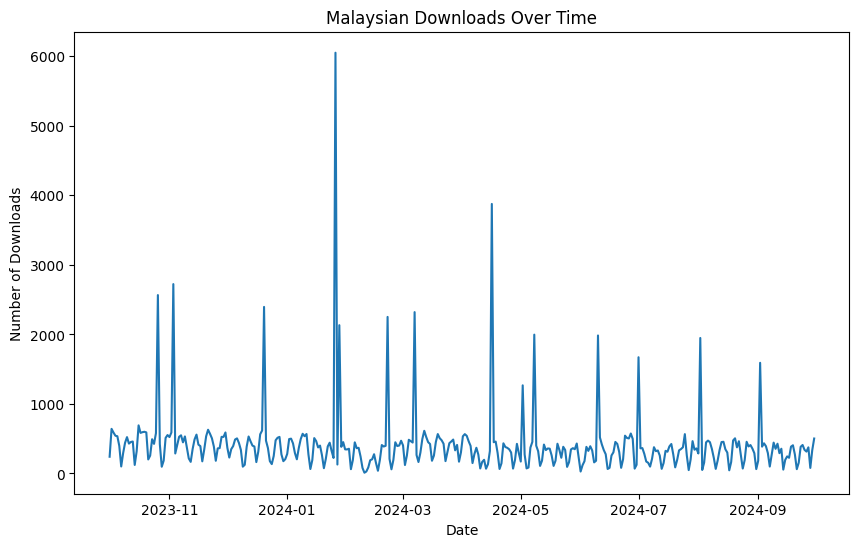

In [19]:
# filter data for Malaysia
malaysia_data = data[data['country'] == 'MY']
malaysia_trends = malaysia_data.groupby(malaysia_data['date_download'].dt.date).size()

# plot Malaysian downloads
plt.figure(figsize = (10, 6))
malaysia_trends.plot(title = "Malaysian Downloads Over Time")
plt.ylabel("Number of Downloads")
plt.xlabel("Date")
plt.show()

In [ ]:
# assuming a CSV file 'malaysia_holidays.csv' exists with a 'date' column
malaysia_holidays = pd.read_csv("malaysia_holidays.csv")
malaysia_holidays['date'] = pd.to_datetime(malaysia_holidays['date'])

# compare download patterns on public holidays vs non-holidays
malaysia_data['is_holiday'] = malaysia_data['date_download'].dt.date.isin(malaysia_holidays['date'].dt.date)
holiday_downloads = malaysia_data.groupby('is_holiday').size()
print(holiday_downloads)


In [ ]:
# categorize users by their download activity
user_download_counts = data['uid'].value_counts()
major_downloaders = user_download_counts[user_download_counts > 50].sum()
small_downloaders = user_download_counts[user_download_counts <= 50].sum()

print(f"Downloads by major downloaders: {major_downloaders}")
print(f"Downloads by small downloaders: {small_downloaders}")


In [ ]:
# analyze fraud patterns
fraud_count = data['fraud'].value_counts()
print(f"Fraud Counts: \n{fraud_count}")

# analyze supplier impact
supplier_trends = data.groupby(['supplier', data['date_download'].dt.date]).size().unstack(fill_value = 0)
supplier_changes = supplier_trends.diff(axis = 1).mean(axis=1).sort_values()

plt.figure(figsize = (10, 6))
supplier_changes.plot(kind = "bar", title = "Average Change in Downloads by Supplier")
plt.ylabel("Average Change in Downloads")
plt.xlabel("Supplier")
plt.show()

Fraud Counts: 
fraud
0    5460260
Name: count, dtype: int64
